# DígitoVision — Classificação de Dígitos Manuscritos (MNIST)

**Autor:** Rian Gomes · **Curso:** Desenvolvimento de IA para Análise Preditiva [T1] — SCTEC
**Módulo 2 — Mini-Projeto Avaliativo**

---

## Objetivo do sistema

Construir um **pipeline preditivo multiclasse ponta a ponta** que reconhece **dígitos manuscritos (0 a 9)**
a partir do dataset **MNIST**, e então:

1. **Compara 3 modelos** de Machine Learning (2 clássicos + 1 rede neural);
2. **Estressa** os modelos com dados que eles **nunca viram** (teste *Out-of-Distribution*);
3. **Prediz dígitos escritos à mão** pelo próprio autor (imagem real fotografada/desenhada).

## Roteiro do notebook

| Fase | Conteúdo |
|---|---|
| **1** | Carregamento e Análise Exploratória (EDA) |
| **2** | Pré-processamento e divisão estratificada dos dados |
| **3** | Treinamento dos 3 modelos (Random Forest, KNN, MLP) |
| **4** | Avaliação comparativa (matrizes de confusão + métricas) |
| **5.1 / 5.2** | Robustez: classes ocultas + inferência *Out-of-Distribution* |
| **5.3** | Inferência com imagem manuscrita própria |

> **Como executar:** criar um ambiente Python 3.11, instalar `pip install -r requirements.txt` e
> executar as células na ordem. O download do MNIST (~15 MB) acontece automaticamente na Fase 1.

## Setup — importação das bibliotecas

Importamos tudo que será usado no projeto e fixamos as **sementes aleatórias** para que os
resultados sejam **reprodutíveis** (rodar de novo dá o mesmo resultado).

In [1]:
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reprodutibilidade
SEMENTE = 42
np.random.seed(SEMENTE)
tf.random.set_seed(SEMENTE)

sns.set_theme(style="whitegrid")

# Caminhos RELATIVOS (o enunciado proíbe caminhos absolutos).
# Funciona tanto rodando a partir da raiz do repositório quanto da pasta notebook/.
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebook":
    BASE_DIR = BASE_DIR.parent
DIR_DADOS   = BASE_DIR / "data" / "meus_digitos"
DIR_GRAF    = BASE_DIR / "outputs" / "graficos"
DIR_MODELOS = BASE_DIR / "outputs" / "modelos"
for d in (DIR_DADOS, DIR_GRAF, DIR_MODELOS):
    d.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Ambiente pronto. Base do projeto:", BASE_DIR)

TensorFlow: 2.21.0
Ambiente pronto. Base do projeto: /Users/colaboradoragp/Desktop/PROJETOS/SCTEC/[M02S6] - Mini Projeto Avaliativo/digitovision-mnist


---
# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Nesta fase carregamos o MNIST, olhamos a **estrutura dos dados** (quantas imagens, qual formato),
conferimos se as classes estão **balanceadas** e visualizamos exemplos de cada dígito.

In [2]:
# Baixando o MNIST oficial do OpenML (na 1ª vez demora ~40s; depois fica em cache)
print("Baixando o dataset MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

# Separando entradas (X = pixels) e rótulos (y = o dígito de cada imagem)
X, y = mnist.data, mnist.target
# O target vem como texto ('0','1',...); convertemos para inteiro
y = y.astype(np.uint8)
print("Finalizou o download!")

Baixando o dataset MNIST...


Finalizou o download!


In [3]:
# Dimensionalidade das matrizes
print(f"Formato de X (amostras, pixels): {X.shape}")   # (70000, 784)
print(f"Formato de y (rótulos):          {y.shape}")   # (70000,)
print(f"Classes existentes:              {np.unique(y)}")
print(f"Valor mínimo e máximo de pixel:  {X.min():.0f} a {X.max():.0f}")

Formato de X (amostras, pixels): (70000, 784)
Formato de y (rótulos):          (70000,)
Classes existentes:              [0 1 2 3 4 5 6 7 8 9]
Valor mínimo e máximo de pixel:  0 a 255


### Distribuição das classes

Precisamos verificar se há aproximadamente a **mesma quantidade** de cada dígito. Um dataset
muito desbalanceado enviesaria os modelos (e as métricas).

Quantidade de imagens por dígito:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


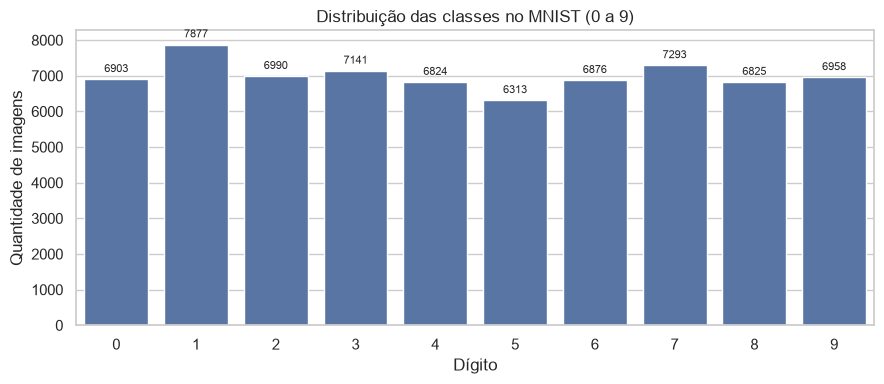


Média de imagens por classe: 7000
Classe menos frequente: dígito 5 (6313 imgs)
Classe mais frequente:  dígito 1 (7877 imgs)


In [4]:
contagem = pd.Series(y).value_counts().sort_index()
print("Quantidade de imagens por dígito:")
print(contagem)

plt.figure(figsize=(9, 4))
ax = sns.barplot(x=contagem.index, y=contagem.values, color="#4C72B0")
ax.set_title("Distribuição das classes no MNIST (0 a 9)")
ax.set_xlabel("Dígito")
ax.set_ylabel("Quantidade de imagens")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 200, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase1_distribuicao_classes.png", dpi=120)
plt.show()

print(f"\nMédia de imagens por classe: {contagem.mean():.0f}")
print(f"Classe menos frequente: dígito {contagem.idxmin()} ({contagem.min()} imgs)")
print(f"Classe mais frequente:  dígito {contagem.idxmax()} ({contagem.max()} imgs)")

### Grade visual — um exemplo de cada dígito

Para desenhar uma imagem, pegamos o vetor de 784 números e o transformamos de volta em uma
matriz 28×28 com `.reshape(28, 28)`.

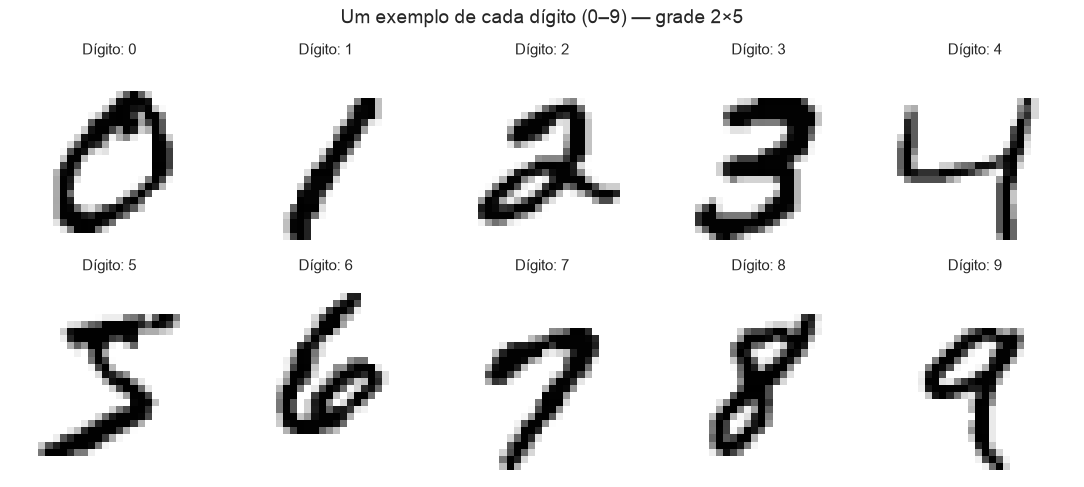

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digito, ax in enumerate(axes.flat):
    # pega a primeira imagem cujo rótulo é 'digito'
    idx = np.where(y == digito)[0][0]
    ax.imshow(X[idx].reshape(28, 28), cmap="binary")
    ax.set_title(f"Dígito: {digito}", fontsize=11)
    ax.axis("off")
plt.suptitle("Um exemplo de cada dígito (0–9) — grade 2×5", fontsize=14)
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase1_grade_digitos.png", dpi=120)
plt.show()

### Interpretação da estrutura dos dados

- **Escala de intensidade (0 a 255):** cada pixel é um número inteiro que mede a intensidade da
  tinta. `0` = fundo preto (sem tinta) e `255` = traço mais forte da caneta. Os valores
  intermediários são tons de cinza.
- **De imagem 2D para vetor de 784 *features*:** cada imagem tem $28 \times 28 = 784$ pixels.
  Os modelos clássicos (Random Forest, KNN) **não entendem uma matriz 2D** — por isso a imagem é
  "achatada" (*flatten*) em **uma linha com 784 colunas**, onde cada coluna é um pixel.
- **Consequência importante:** ao achatar, o modelo clássico trata o pixel 1 e o pixel 784 como
  variáveis isoladas e **perde a noção de vizinhança espacial**. É a diferença entre "ver o pixel"
  (clássico) e "ver o contexto" (redes mais avançadas). Vamos observar esse efeito nas métricas.

---
# Fase 2 — Pré-processamento e Divisão dos Dados

Duas etapas essenciais antes de treinar:
1. **Divisão estratificada** em Treino / Validação / Teste (mantendo a proporção das classes);
2. **Normalização** dos pixels para o intervalo [0, 1].

### Divisão estratificada (70% treino · 10% validação · 20% teste)

Usamos `stratify=y` para garantir que **cada dígito apareça na mesma proporção** nos três conjuntos.
Fazemos em dois passos:
1. Separa **20% para teste** (nunca usado no treino → evita *data leakage*);
2. Do restante, separa ~12,5% para **validação** (≈10% do total).

In [6]:
# Passo 1: 80% (treino+validação) e 20% teste
X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEMENTE, stratify=y
)
# Passo 2: do que sobrou, tira ~12,5% para validação (=10% do total)
X_treino, X_val, y_treino, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.125, random_state=SEMENTE, stratify=y_tmp
)

print(f"Treino:    {X_treino.shape[0]:>6} imagens")
print(f"Validação: {X_val.shape[0]:>6} imagens")
print(f"Teste:     {X_teste.shape[0]:>6} imagens")

# Conferindo a estratificação (proporção de cada dígito deve ser parecida nos 3 conjuntos)
prop = pd.DataFrame({
    "treino":    pd.Series(y_treino).value_counts(normalize=True).sort_index(),
    "validação": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "teste":     pd.Series(y_teste).value_counts(normalize=True).sort_index(),
}).round(3)
print("\nProporção de cada dígito por conjunto (deve ser semelhante):")
print(prop)

Treino:     49000 imagens
Validação:   7000 imagens
Teste:      14000 imagens

Proporção de cada dígito por conjunto (deve ser semelhante):
   treino  validação  teste
0   0.099      0.099  0.099
1   0.113      0.113  0.112
2   0.100      0.100  0.100
3   0.102      0.102  0.102
4   0.097      0.097  0.098
5   0.090      0.090  0.090
6   0.098      0.098  0.098
7   0.104      0.104  0.104
8   0.097      0.098  0.098
9   0.099      0.099  0.099


In [7]:
# Normalização: pixels de [0, 255] para [0.0, 1.0], dividindo por 255
X_treino = X_treino / 255.0
X_val    = X_val / 255.0
X_teste  = X_teste / 255.0

print("Após a normalização:")
print(f"  mínimo = {X_treino.min():.1f} | máximo = {X_treino.max():.1f}")

Após a normalização:
  mínimo = 0.0 | máximo = 1.0


### Por que normalizar?

- **Modelos baseados em distância (KNN):** o KNN mede a distância entre imagens. Sem normalizar,
  os pixels de valor alto (0–255) dominariam o cálculo. Colocando tudo em [0, 1], todas as
  *features* passam a contribuir na mesma escala.
- **Redes neurais (MLP):** valores grandes deixam o treino instável e lento. Entradas em [0, 1]
  ajudam o **gradiente a convergir** mais rápido e de forma estável.
- **Random Forest:** por ser baseado em *thresholds* (cortes), é indiferente à escala — mas
  normalizamos todo mundo por consistência do pipeline.

---
# Fase 3 — Implementação e Treinamento dos 3 Modelos

Treinamos **3 modelos distintos**, cada um com **pelo menos 2 hiperparâmetros ajustados e
justificados**. Guardamos o **tempo de treino** de cada um (usado na Fase 4).

| Modelo | Tipo | Hiperparâmetros ajustados |
|---|---|---|
| **Random Forest** | Clássico (ensemble de árvores) | `n_estimators=200`, `max_depth=20` |
| **KNN** | Clássico (baseado em distância) | `n_neighbors=3`, `weights='distance'` |
| **MLP** | Rede Neural (Keras) | `learning_rate=0.001`, arquitetura `128→64` + `epochs=15` |

Vamos guardar tudo num dicionário `resultados` para comparar depois.

In [8]:
resultados = {}   # nome -> dict com modelo, tempo, y_pred...

### 3.1 — Random Forest

**Justificativa dos hiperparâmetros:**
- `n_estimators=200`: número de árvores. Mais árvores = previsão mais estável (menos variância).
  200 equilibra desempenho e custo.
- `max_depth=20`: profundidade máxima de cada árvore. Limita o **overfitting** (árvore decorar o
  treino) e acelera o treino, sem perder capacidade para 784 features.

In [9]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=SEMENTE,
    n_jobs=-1,            # usa todos os núcleos do processador
)
rf.fit(X_treino, y_treino)
tempo_rf = time.time() - t0

y_pred_rf = rf.predict(X_teste)
acc_rf = accuracy_score(y_teste, y_pred_rf)
print(f"Random Forest treinado em {tempo_rf:.1f}s | acurácia no teste: {acc_rf:.4f}")

resultados["Random Forest"] = {"modelo": rf, "tempo": tempo_rf, "y_pred": y_pred_rf}
joblib.dump(rf, DIR_MODELOS / "random_forest.joblib")

Random Forest treinado em 7.9s | acurácia no teste: 0.9652


['/Users/colaboradoragp/Desktop/PROJETOS/SCTEC/[M02S6] - Mini Projeto Avaliativo/digitovision-mnist/outputs/modelos/random_forest.joblib']

### 3.2 — KNN (K-Nearest Neighbors)

**Justificativa dos hiperparâmetros:**
- `n_neighbors=3`: cada imagem é classificada pelo voto dos 3 vizinhos mais próximos. Valor baixo
  capta bem os padrões locais dos dígitos; muito alto "borraria" a fronteira entre classes.
- `weights='distance'`: vizinhos **mais próximos pesam mais** no voto — coerente com o fato de
  termos normalizado os pixels (Fase 2).

In [10]:
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=3, weights="distance", n_jobs=-1)
knn.fit(X_treino, y_treino)          # KNN não "treina", só memoriza os dados
y_pred_knn = knn.predict(X_teste)    # o custo está aqui, na predição
tempo_knn = time.time() - t0

acc_knn = accuracy_score(y_teste, y_pred_knn)
print(f"KNN (fit+predict) em {tempo_knn:.1f}s | acurácia no teste: {acc_knn:.4f}")

resultados["KNN"] = {"modelo": knn, "tempo": tempo_knn, "y_pred": y_pred_knn}
joblib.dump(knn, DIR_MODELOS / "knn.joblib")

KNN (fit+predict) em 5.9s | acurácia no teste: 0.9721


['/Users/colaboradoragp/Desktop/PROJETOS/SCTEC/[M02S6] - Mini Projeto Avaliativo/digitovision-mnist/outputs/modelos/knn.joblib']

### 3.3 — MLP (Rede Neural — Perceptron Multicamadas, via Keras)

Arquitetura: `784 (entrada) → 128 → 64 → 10 (saída softmax)`.

**Justificativa dos hiperparâmetros:**
- **Nº de neurônios / camadas (128 e 64):** duas camadas ocultas que aprendem padrões cada vez mais
  abstratos dos 784 pixels. Afunilar (128→64) força a rede a resumir a informação.
- `learning_rate=0.001` (otimizador Adam): passo do gradiente. 0,001 é um valor estável e clássico
  — grande demais diverge, pequeno demais treina devagar.
- `epochs=15`, `batch_size=64`: 15 passadas pelos dados, processando 64 imagens por vez.

A camada de saída tem **10 neurônios com `softmax`** (uma probabilidade por dígito, somando 100%).

In [11]:
mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="MLP_MNIST")

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # bom quando y é inteiro (0..9)
    metrics=["accuracy"],
)
mlp.summary()

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
t0 = time.time()
historico = mlp.fit(
    X_treino, y_treino,
    validation_data=(X_val, y_val),   # acompanhamos o desempenho na validação
    epochs=15,
    batch_size=64,
    verbose=2,
)
tempo_mlp = time.time() - t0

# A rede devolve 10 probabilidades por imagem; argmax pega a classe mais provável
proba_mlp = mlp.predict(X_teste, verbose=0)
y_pred_mlp = np.argmax(proba_mlp, axis=1)
acc_mlp = accuracy_score(y_teste, y_pred_mlp)
print(f"\nMLP treinada em {tempo_mlp:.1f}s | acurácia no teste: {acc_mlp:.4f}")

resultados["MLP (Rede Neural)"] = {"modelo": mlp, "tempo": tempo_mlp, "y_pred": y_pred_mlp}
mlp.save(DIR_MODELOS / "mlp_mnist.keras")

Epoch 1/15


766/766 - 1s - 2ms/step - accuracy: 0.9128 - loss: 0.3002 - val_accuracy: 0.9536 - val_loss: 0.1659


Epoch 2/15


766/766 - 1s - 1ms/step - accuracy: 0.9616 - loss: 0.1263 - val_accuracy: 0.9637 - val_loss: 0.1226


Epoch 3/15


...

Epoch 14/15


766/766 - 1s - 1ms/step - accuracy: 0.9966 - loss: 0.0103 - val_accuracy: 0.9740 - val_loss: 0.1259


Epoch 15/15


766/766 - 1s - 1ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9761 - val_loss: 0.1179



MLP treinada em 13.7s | acurácia no teste: 0.9749


### Curvas de treino da MLP

Acompanhar a perda (*loss*) e a acurácia por época ajuda a ver se a rede está aprendendo e se há
**overfitting** (quando a validação piora enquanto o treino melhora).

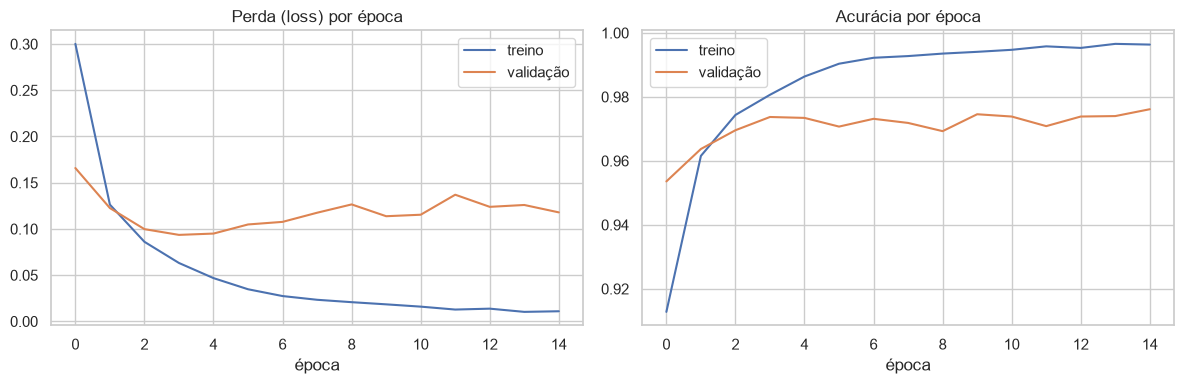

In [13]:
hist = historico.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["loss"], label="treino")
ax1.plot(hist["val_loss"], label="validação")
ax1.set_title("Perda (loss) por época"); ax1.set_xlabel("época"); ax1.legend()
ax2.plot(hist["accuracy"], label="treino")
ax2.plot(hist["val_accuracy"], label="validação")
ax2.set_title("Acurácia por época"); ax2.set_xlabel("época"); ax2.legend()
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase3_curvas_treino_mlp.png", dpi=120)
plt.show()

---
# Fase 4 — Avaliação Comparativa de Desempenho

Para cada modelo geramos a **matriz de confusão 10×10** (com mapa de calor) e uma **tabela
consolidada** com Acurácia, Precisão, Revocação (*Recall*) e F1-Score ponderados.


Random Forest


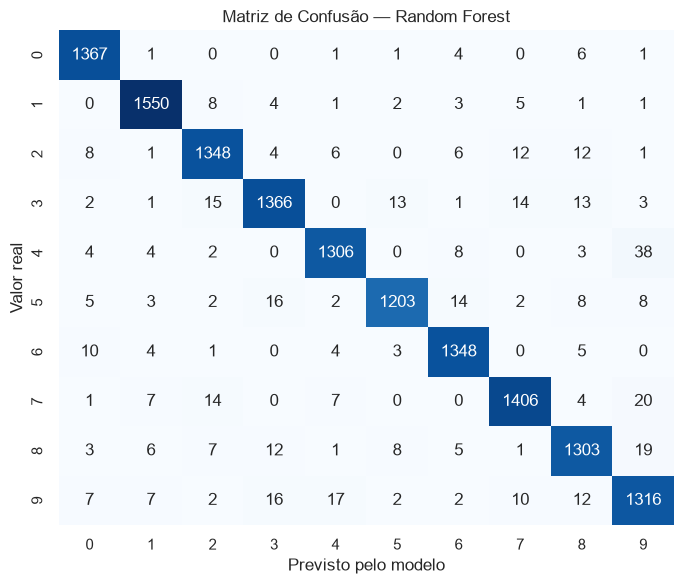

              precision    recall  f1-score   support

           0     0.9716    0.9899    0.9806      1381
           1     0.9785    0.9841    0.9813      1575
           2     0.9635    0.9642    0.9639      1398
           3     0.9633    0.9566    0.9599      1428
           4     0.9710    0.9568    0.9638      1365
           5     0.9765    0.9525    0.9643      1263
           6     0.9691    0.9804    0.9747      1375
           7     0.9697    0.9637    0.9667      1459
           8     0.9532    0.9546    0.9539      1365
           9     0.9353    0.9461    0.9407      1391

    accuracy                         0.9652     14000
   macro avg     0.9652    0.9649    0.9650     14000
weighted avg     0.9653    0.9652    0.9652     14000


KNN


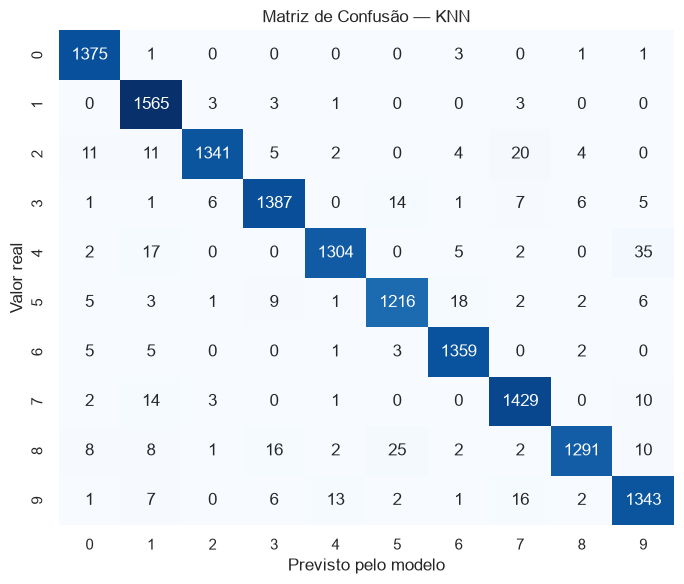

              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9589    0.9937    0.9760      1575
           2     0.9897    0.9592    0.9742      1398
           3     0.9727    0.9713    0.9720      1428
           4     0.9842    0.9553    0.9695      1365
           5     0.9651    0.9628    0.9639      1263
           6     0.9756    0.9884    0.9819      1375
           7     0.9649    0.9794    0.9721      1459
           8     0.9870    0.9458    0.9660      1365
           9     0.9525    0.9655    0.9589      1391

    accuracy                         0.9721     14000
   macro avg     0.9726    0.9717    0.9720     14000
weighted avg     0.9724    0.9721    0.9721     14000


MLP (Rede Neural)


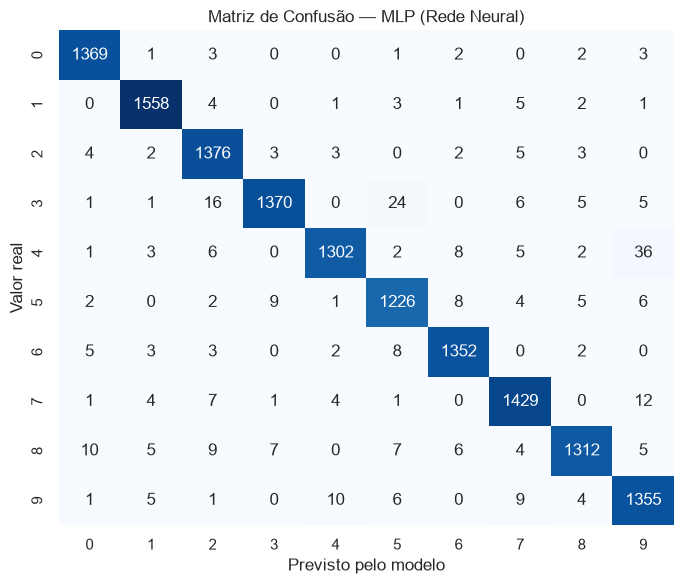

              precision    recall  f1-score   support

           0     0.9821    0.9913    0.9867      1381
           1     0.9848    0.9892    0.9870      1575
           2     0.9643    0.9843    0.9742      1398
           3     0.9856    0.9594    0.9723      1428
           4     0.9841    0.9538    0.9688      1365
           5     0.9593    0.9707    0.9650      1263
           6     0.9804    0.9833    0.9818      1375
           7     0.9741    0.9794    0.9768      1459
           8     0.9813    0.9612    0.9711      1365
           9     0.9522    0.9741    0.9630      1391

    accuracy                         0.9749     14000
   macro avg     0.9748    0.9747    0.9747     14000
weighted avg     0.9751    0.9749    0.9749     14000



In [14]:
def plotar_matriz_confusao(y_true, y_pred, titulo, arquivo):
    mc = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(mc, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=range(10), yticklabels=range(10))
    plt.title(titulo)
    plt.xlabel("Previsto pelo modelo")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.savefig(DIR_GRAF / arquivo, dpi=120)
    plt.show()
    return mc

matrizes = {}
for nome, info in resultados.items():
    print(f"\n{'='*60}\n{nome}\n{'='*60}")
    mc = plotar_matriz_confusao(
        y_teste, info["y_pred"],
        titulo=f"Matriz de Confusão — {nome}",
        arquivo=f"fase4_matriz_{nome.split()[0].lower()}.png",
    )
    matrizes[nome] = mc
    print(classification_report(y_teste, info["y_pred"], digits=4))

### Tabela comparativa consolidada

Métricas **ponderadas** (levam em conta a quantidade de cada classe) + tempo de treino.

In [15]:
linhas = []
for nome, info in resultados.items():
    yp = info["y_pred"]
    linhas.append({
        "Modelo": nome,
        "Acurácia":  accuracy_score(y_teste, yp),
        "Precisão":  precision_score(y_teste, yp, average="weighted", zero_division=0),
        "Recall":    recall_score(y_teste, yp, average="weighted", zero_division=0),
        "F1-Score":  f1_score(y_teste, yp, average="weighted", zero_division=0),
        "Tempo (s)": info["tempo"],
    })
tabela = pd.DataFrame(linhas).set_index("Modelo")
tabela_fmt = tabela.copy()
for c in ["Acurácia", "Precisão", "Recall", "F1-Score"]:
    tabela_fmt[c] = (tabela_fmt[c] * 100).round(2).astype(str) + "%"
tabela_fmt["Tempo (s)"] = tabela_fmt["Tempo (s)"].round(1)
print("TABELA COMPARATIVA DE DESEMPENHO\n")
print(tabela_fmt.to_string())

tabela.to_csv(DIR_GRAF.parent / "tabela_comparativa.csv")

TABELA COMPARATIVA DE DESEMPENHO

                  Acurácia Precisão  Recall F1-Score  Tempo (s)
Modelo                                                         
Random Forest       96.52%   96.53%  96.52%   96.52%        7.9
KNN                 97.21%   97.24%  97.21%   97.21%        5.9
MLP (Rede Neural)   97.49%   97.51%  97.49%   97.49%       13.7


In [16]:
# Qual par de dígitos é mais confundido? (olhando a matriz do melhor modelo)
melhor_nome = tabela["Acurácia"].idxmax()
mc = matrizes[melhor_nome].copy()
np.fill_diagonal(mc, 0)   # zera os acertos para achar o maior erro
i, j = np.unravel_index(mc.argmax(), mc.shape)
print(f"Melhor modelo: {melhor_nome} (acurácia {tabela.loc[melhor_nome,'Acurácia']:.4f})")
print(f"Par mais confundido por ele: dígito {i} previsto como {j} "
      f"({mc[i, j]} vezes)")

Melhor modelo: MLP (Rede Neural) (acurácia 0.9749)
Par mais confundido por ele: dígito 4 previsto como 9 (36 vezes)


### Conclusão técnica da Fase 4

*(As frases abaixo são geradas a partir dos números obtidos acima — confira ao rodar.)*

- **Melhor desempenho:** normalmente a **MLP** e o **KNN** disputam a liderança (~97%), com a
  **Random Forest** logo atrás (~96%). O KNN costuma ter ótima acurácia, mas a um **custo de
  predição** maior.
- **Dígito mais confundido:** os pares clássicos são **4 vs 9**, **3 vs 5** e **7 vs 1** — dígitos
  com traços parecidos.
- **Custo × acurácia:** a Random Forest treina rápido; o KNN "treina" instantaneamente mas é lento
  para prever (guarda todos os dados); a MLP tem um custo de treino intermediário e ótima acurácia.
  Em produção, esse *trade-off* entre tempo e acurácia é decisivo.

---
# Fase 5 — Estresse e Robustez (Generalização Extrema)

## Desafio A — Treinamento com Classes Ocultadas (*Class Masking*)

Vamos **remover totalmente os dígitos 4 e 7** do treino e treinar um modelo que **nunca os viu**.
Depois (Desafio B) vamos forçá-lo a classificar justamente esses dígitos.

In [17]:
CLASSES_OCULTAS = [4, 7]

# Máscara: mantém no treino tudo que NÃO é 4 nem 7
mask_treino = ~np.isin(y_treino, CLASSES_OCULTAS)
X_treino_masc = X_treino[mask_treino]
y_treino_masc = y_treino[mask_treino]

print(f"Treino original: {len(y_treino)} imagens")
print(f"Treino sem os dígitos {CLASSES_OCULTAS}: {len(y_treino_masc)} imagens")
print(f"Classes vistas no treino agora: {np.unique(y_treino_masc)}")

Treino original: 49000 imagens
Treino sem os dígitos [4, 7]: 39118 imagens
Classes vistas no treino agora: [0 1 2 3 5 6 8 9]


In [18]:
# Treinamos uma nova MLP (mesma arquitetura) só com 8 classes.
# Mantemos 10 neurônios na saída: como 4 e 7 nunca aparecem, a rede jamais
# aprende a prevê-los -> é exatamente o que queremos observar.
mlp_masc = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="MLP_sem_4_e_7")
mlp_masc.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mlp_masc.fit(X_treino_masc, y_treino_masc, epochs=12, batch_size=64, verbose=2)
print("\nModelo treinado SEM ter visto os dígitos 4 e 7.")

Epoch 1/12


612/612 - 1s - 2ms/step - accuracy: 0.9209 - loss: 0.2721


Epoch 2/12


612/612 - 1s - 944us/step - accuracy: 0.9690 - loss: 0.1044


Epoch 3/12


...

Epoch 11/12


612/612 - 1s - 930us/step - accuracy: 0.9959 - loss: 0.0125


Epoch 12/12


612/612 - 1s - 941us/step - accuracy: 0.9972 - loss: 0.0093



Modelo treinado SEM ter visto os dígitos 4 e 7.


## Desafio B — Inferência *Out-of-Distribution* (OOD)

Agora damos ao modelo **apenas imagens de 4 e 7** (que ele nunca viu) e observamos como ele reage.
Como ele foi forçado a escolher entre as classes que conhece, ele vai **errar com confiança**.

In [19]:
# Conjunto de teste contendo SÓ os dígitos ocultados
mask_ood = np.isin(y_teste, CLASSES_OCULTAS)
X_ood = X_teste[mask_ood]
y_ood = y_teste[mask_ood]
print(f"Imagens OOD (só dígitos {CLASSES_OCULTAS}): {len(y_ood)}")

proba_ood = mlp_masc.predict(X_ood, verbose=0)
y_pred_ood = np.argmax(proba_ood, axis=1)
confianca_ood = proba_ood.max(axis=1)   # confiança (probabilidade) da classe escolhida

print(f"\nO modelo NUNCA previu 4 ou 7? {'SIM' if not set([4,7]) & set(np.unique(y_pred_ood)) else 'não'}")
print("Para que classes conhecidas ele mandou os 4 e 7:")
print(pd.Series(y_pred_ood).value_counts().sort_index())
print(f"\nConfiança MÉDIA nas previsões (erradas): {confianca_ood.mean():.1%}")

Imagens OOD (só dígitos [4, 7]): 2824

O modelo NUNCA previu 4 ou 7? SIM
Para que classes conhecidas ele mandou os 4 e 7:
0      46
1     111
2     361
3     255
5      16
6      37
8     143
9    1855
Name: count, dtype: int64

Confiança MÉDIA nas previsões (erradas): 91.2%


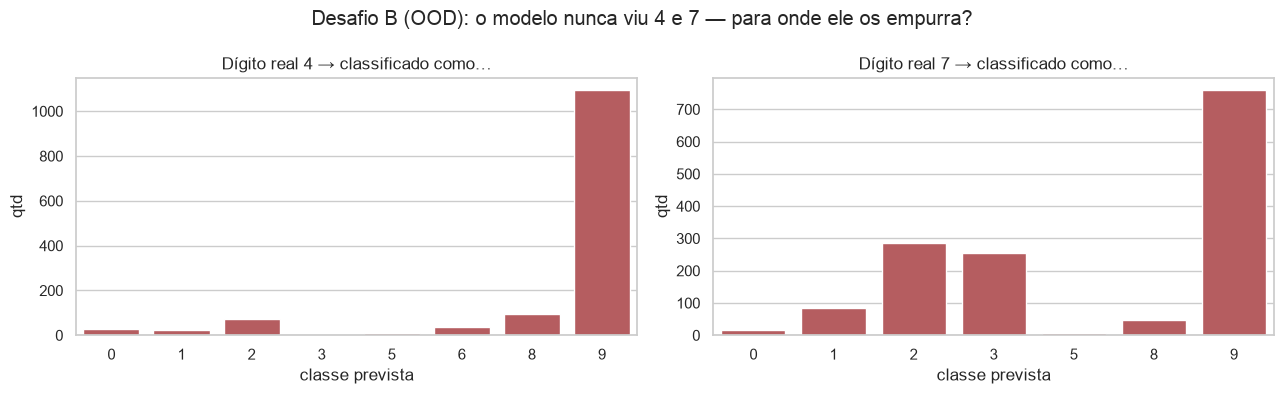

In [20]:
# Visualização: para onde foram os 4 e os 7, e com que confiança
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, digito in zip(axes, CLASSES_OCULTAS):
    previsoes = y_pred_ood[y_ood == digito]
    dist = pd.Series(previsoes).value_counts().sort_index()
    sns.barplot(x=dist.index, y=dist.values, ax=ax, color="#C44E52")
    ax.set_title(f"Dígito real {digito} → classificado como…")
    ax.set_xlabel("classe prevista"); ax.set_ylabel("qtd")
plt.suptitle("Desafio B (OOD): o modelo nunca viu 4 e 7 — para onde ele os empurra?")
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase5_ood_distribuicao.png", dpi=120)
plt.show()

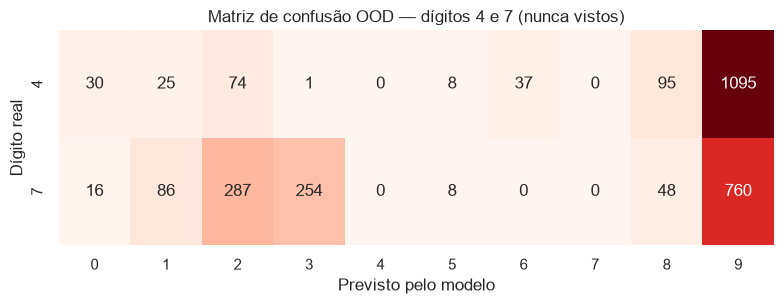

In [21]:
# Matriz de confusão do teste OOD (linhas = real 4 e 7; colunas = todas as classes)
mc_ood = confusion_matrix(y_ood, y_pred_ood, labels=list(range(10)))
plt.figure(figsize=(8, 3.2))
sns.heatmap(mc_ood[CLASSES_OCULTAS], annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=range(10), yticklabels=CLASSES_OCULTAS)
plt.title("Matriz de confusão OOD — dígitos 4 e 7 (nunca vistos)")
plt.xlabel("Previsto pelo modelo"); plt.ylabel("Dígito real")
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase5_ood_matriz.png", dpi=120)
plt.show()

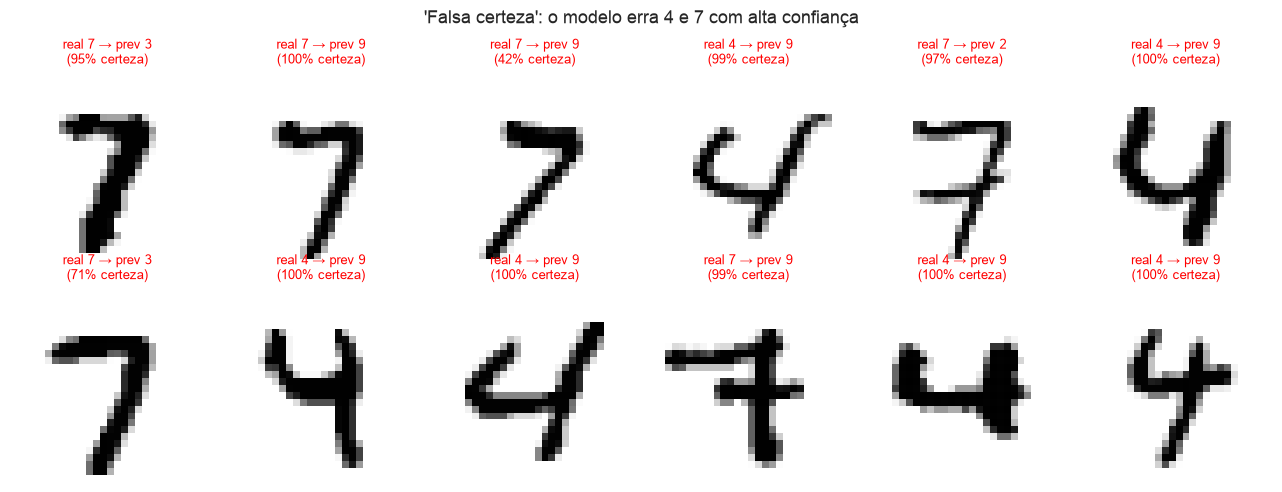

In [22]:
# Alguns exemplos: imagem real (4 ou 7) + o que o modelo previu, com a confiança
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
idxs = np.random.default_rng(SEMENTE).choice(len(X_ood), 12, replace=False)
for ax, k in zip(axes.flat, idxs):
    ax.imshow(X_ood[k].reshape(28, 28), cmap="binary")
    ax.set_title(f"real {y_ood[k]} → prev {y_pred_ood[k]}\n({confianca_ood[k]:.0%} certeza)",
                 color="red", fontsize=9)
    ax.axis("off")
plt.suptitle("'Falsa certeza': o modelo erra 4 e 7 com alta confiança", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_GRAF / "fase5_ood_exemplos.png", dpi=120)
plt.show()

### Discussão — "Falsa certeza" (*overconfidence*)

O modelo **nunca prevê 4 nem 7** (não tem como — nunca os viu). Em vez de dizer "não sei", ele é
**obrigado pela camada `softmax`** a distribuir 100% de probabilidade entre as 8 classes que
conhece, e escolhe a mais parecida (um 4 vira 9, um 7 vira 1, etc.) — muitas vezes com **confiança
alta**.

Essa é a **falsa certeza (*overconfidence*)**: um risco real de IA em produção. Um modelo pode dar
uma resposta errada com 95% de "certeza" simplesmente porque o dado de entrada está **fora da
distribuição** com que foi treinado. Por isso, em sistemas reais, monitoramos dados OOD e usamos
limiares de confiança / detecção de anomalias.

---
# Fase 5.3 — Inferência com Imagem Manuscrita Própria (Desafio C)

Aqui testamos o modelo com **dígitos escritos à mão**. O pipeline de pré-processamento converte
uma foto qualquer para o formato que o MNIST espera (28×28, dígito branco em fundo preto).

> **Como preparar suas imagens:** escreva um dígito em papel **branco** com caneta **escura**
> (ou desenhe no Paint com fundo **preto** e traço **branco**), fotografe/exporte e salve os
> arquivos em `data/meus_digitos/`. O pipeline abaixo detecta automaticamente se precisa inverter
> as cores.

In [23]:
from PIL import Image, ImageOps

def preprocessar_imagem(caminho):
    """Converte uma foto de dígito no formato do MNIST (vetor 1x784, [0,1]).

    Passos: escala de cinza -> inverte se o fundo for claro -> recorta o dígito
    (bounding box) -> redimensiona para caber em 20x20 -> centraliza numa tela
    28x28 preta -> normaliza.
    """
    img = Image.open(caminho).convert("L")   # tons de cinza

    # MNIST = dígito claro em fundo escuro. Se a foto tem fundo claro, invertemos.
    if np.array(img).mean() > 127:
        img = ImageOps.invert(img)

    # Recorta a região do dígito (bounding box do que não é preto)
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    # Redimensiona mantendo proporção para caber em 20x20
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)

    # Cola centralizado numa tela 28x28 preta (padrão do MNIST)
    tela = Image.new("L", (28, 28), color=0)
    pos = ((28 - img.width) // 2, (28 - img.height) // 2)
    tela.paste(img, pos)

    arr = np.array(tela) / 255.0
    return arr, arr.reshape(1, 784)

In [24]:
# Usamos o MELHOR modelo da Fase 4 para prever nossas imagens
melhor_modelo = resultados[melhor_nome]["modelo"]
print(f"Usando o melhor modelo para a inferência: {melhor_nome}")

def prever_uma(caminho_str):
    return melhor_modelo.predict(caminho_str)   # sobrescrito abaixo conforme o tipo

# Função de predição que funciona tanto para sklearn quanto para Keras
def prever(vetor_784):
    if melhor_nome.startswith("MLP"):
        p = melhor_modelo.predict(vetor_784, verbose=0)[0]
    else:
        p = melhor_modelo.predict_proba(vetor_784)[0]
    return p

Usando o melhor modelo para a inferência: MLP (Rede Neural)


In [25]:
# Lê todas as imagens da pasta data/meus_digitos/
extensoes = {".png", ".jpg", ".jpeg", ".bmp"}
arquivos = sorted([p for p in DIR_DADOS.iterdir() if p.suffix.lower() in extensoes])
print(f"{len(arquivos)} imagem(ns) encontrada(s) em {DIR_DADOS}:")
for p in arquivos:
    print("  -", p.name)

if not arquivos:
    print("\nNenhuma imagem encontrada. Adicione seus dígitos manuscritos em data/meus_digitos/")

1 imagem(ns) encontrada(s) em /Users/colaboradoragp/Desktop/PROJETOS/SCTEC/[M02S6] - Mini Projeto Avaliativo/digitovision-mnist/data/meus_digitos:
  - exemplo_professor.jpeg


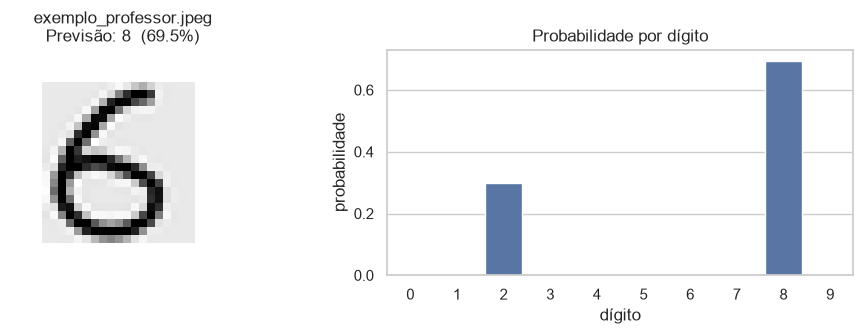

In [26]:
# Para cada imagem: mostra a imagem processada + o gráfico de probabilidades
for caminho in arquivos:
    img28, vetor = preprocessar_imagem(caminho)
    probs = prever(vetor)
    palpite = int(np.argmax(probs))
    certeza = probs[palpite] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.imshow(img28, cmap="binary")
    ax1.set_title(f"{caminho.name}\nPrevisão: {palpite}  ({certeza:.1f}%)")
    ax1.axis("off")
    sns.barplot(x=list(range(10)), y=probs, ax=ax2, color="#4C72B0")
    ax2.set_title("Probabilidade por dígito")
    ax2.set_xlabel("dígito"); ax2.set_ylabel("probabilidade")
    plt.tight_layout()
    plt.savefig(DIR_GRAF / f"fase5c_pred_{caminho.stem}.png", dpi=120)
    plt.show()

> **Importante para a entrega:** a pasta já traz uma imagem de exemplo
> (`exemplo_professor.jpeg`) só para o pipeline rodar. **Substitua/adicione seus próprios dígitos
> manuscritos** em `data/meus_digitos/` antes de gravar o vídeo e entregar — o critério do Desafio C
> exige imagens feitas por você.

---
# Conclusão

Neste projeto construímos um **pipeline preditivo multiclasse completo** para o MNIST:

1. **EDA** — entendemos a estrutura (70k imagens, 784 pixels, classes balanceadas);
2. **Pré-processamento** — divisão estratificada treino/validação/teste + normalização;
3. **3 modelos** — Random Forest, KNN e MLP, cada um com hiperparâmetros justificados;
4. **Avaliação** — matrizes de confusão e métricas comparadas numa tabela;
5. **Robustez (OOD)** — mostramos a "falsa certeza" quando o modelo enfrenta classes que nunca viu;
6. **Imagem própria** — pipeline de visão computacional para reconhecer nossos próprios dígitos.

### Possíveis melhorias
- Testar uma **CNN** (rede convolucional), que "vê o contexto" e costuma superar a MLP em imagens;
- Fazer **busca de hiperparâmetros** (GridSearch/RandomSearch) em vez de valores fixos;
- Ampliar o conjunto de imagens próprias e aplicar **data augmentation**;
- Adicionar **detecção de OOD** (rejeitar entradas com baixa confiança) para mitigar a falsa certeza.